# Regression with Flux.jl

- toc: true 
- hide: false 
- badges: true
- comments: true
- categories: [machine learning, Flux]
- permalink: /regression_flux/

Currently a Julia1.6 incompatibility issue with SpecialMatrices.jl so I took only the Vandermonde.jl module https://github.com/JuliaMatrices/SpecialMatrices.jl/blob/master/src/vandermonde.jl

In [1]:
using Flux, Plots, Random, DataFrames, PyCall, LinearAlgebra, Polynomials

Rather than define myself, checkout [Polynomials.jl](https://github.com/JuliaMath/Polynomials.jl)

In [2]:
poly(x, weights) = map(x -> evalpoly(x, weights), x) .+ sigma*randn(size(x))

poly (generic function with 1 method)

In [3]:
weights = [0, 3, -1.4, -4, 2]
sigma = 0.6

X = LinRange(-1, 1, 100)
y = map(x -> evalpoly(x, weights), X) .+ sigma*randn(size(X));

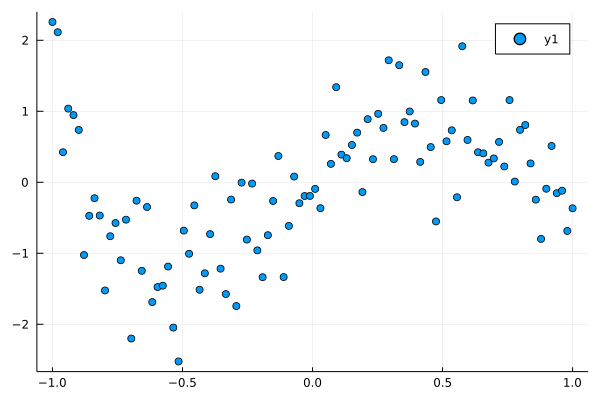

In [4]:
scatter(X, y)

In [5]:
Random.seed!(42)
"""
From <https://stackoverflow.com/questions/66059128/splitting-datasets-into-train-and-test-in-julia>
"""
function splitdf(df, pct)
    @assert 0 <= pct <= 1
    ids = collect(axes(df, 1))
    shuffle!(ids)
    sel = ids .<= nrow(df) .* pct
    return df[sel, :], df[.!sel, :]
end

function train_test_split(x, y; test_size=0.25)
    train, test = splitdf(DataFrame(x=x, y=y), 1-test_size)
    return collect.([train.x, test.x, train.y, test.y])
end

train_test_split (generic function with 1 method)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y; test_size=0.33)
size.([X_train, X_test, y_train, y_test])

4-element Vector{Tuple{Int64}}:
 (67,)
 (33,)
 (67,)
 (33,)

Because of the julia 1.6 error with SpecialMatrices.jl I need to use Pycall to use numpy's vandermonde implementation

In [7]:
np = pyimport("numpy")

PyObject <module 'numpy' from 'C:\\Users\\bnel1\\.julia\\conda\\3\\lib\\site-packages\\numpy\\__init__.py'>

In [8]:
Nparams = 4
A = np.vander(X_train, N=Nparams, increasing=true)
c = A \ y_train

4-element Vector{Float64}:
 -0.1593117031876937
  3.415455042440976
  0.3033164249528293
 -4.464118022735505

In [9]:
vander_model(x, w) = np.vander(x, N=length(w), increasing=true)*w

vander_model (generic function with 1 method)

In [10]:
get_model_losses(model) = return norm(model(X_train) - y_train, 2), norm(model(X_test) - y_test, 2)

get_model_losses (generic function with 1 method)

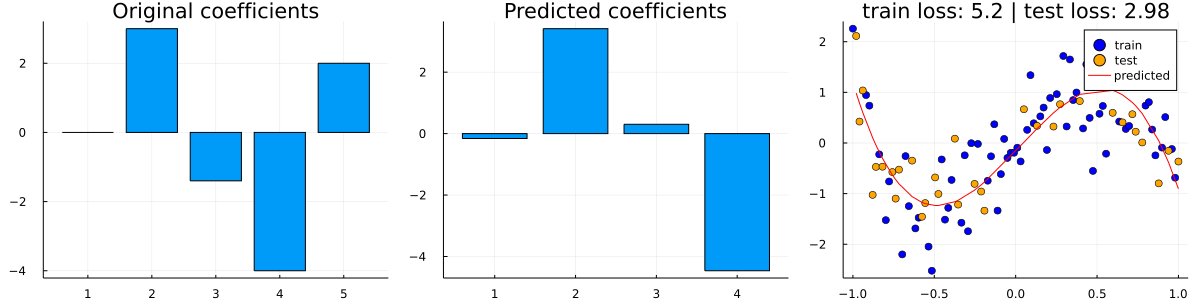

In [11]:
function eval_model(model, params; name="")
    y_pred = model(X_test)
    train_loss, test_loss = get_model_losses(x -> vander_model(x, c))
    p1 = bar(range(1, length(weights), step=1), weights, legend=false, title="Original coefficients")
    p2 = bar(range(1, length(c), step=1), c, legend=false, title="Predicted coefficients")
    p3 = scatter(X_train, y_train, color="blue", label="train")
    p3 = scatter!(X_test, y_test, color="orange", label="test")
    train_loss, test_loss = map(x -> round(x, digits=2), [train_loss, test_loss])
    p3 = plot!(X_test, y_pred, color="red", label="predicted", title="train loss: $train_loss | test loss: $test_loss")
    plot(p1, p2, p3, layout=(1,3), size=(1200,300))
end

eval_model(x -> vander_model(x, c), c)

## Train with Flux

<https://fluxml.ai/Flux.jl/stable/models/basics/>

In [12]:
W = randn(size(weights))

5-element Vector{Float64}:
 -0.4306357340413131
 -0.05292489819141157
  0.7631065933222378
 -1.7078224461664113
 -0.665051961459703

In [13]:
function polynomial(x, W)
   ind = 0
end

polynomial (generic function with 1 method)

In [14]:
model(x) = poly(x, W)

model (generic function with 1 method)

In [15]:
loss(x, y) = sum((y .- model(x)).^2)

loss (generic function with 1 method)

In [16]:
loss(X_train, y_train)

149.21064965009407

In [17]:
gs = gradient(() -> loss(X_train, y_train), params(W))

Grads(...)

In [18]:
W̄ = gs[W]

W .-= 0.001 .* W̄

5-element Vector{Float64}:
 -0.3811071068771457
  0.02275490905102196
  0.7828959474999156
 -1.6743053580925873
 -0.6481165038224512

In [19]:
loss(X_train, y_train)

155.73792515832773

In [20]:
using IterTools: ncycle
using Flux: @epochs
using Flux.Data: DataLoader
import Flux.Optimise.train!

In [21]:
data = DataLoader(X_train, y_train);

In [22]:
lr=0.001
nepochs = 500
W = randn(size(weights))
model(x) = poly(x, W)
loss(x, y) = sum((y .- model(x)).^2)

for _ in range(1, nepochs, step=1)
    train!(loss, params(W), data, Flux.Optimise.Descent(lr))
end

For some reason `poly` freaks out with W 

In [23]:
mypoly(x, w) = sum([c .* x .^(i - 1) for (i,c) in enumerate(w)])

mypoly (generic function with 1 method)

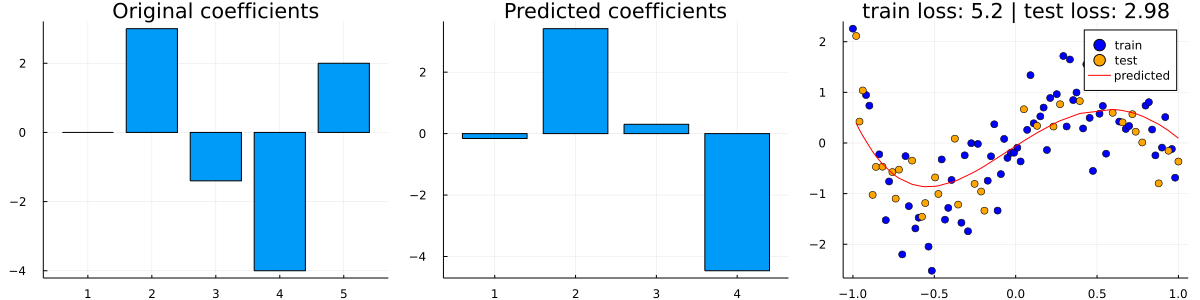

In [24]:
eval_model(x -> mypoly(x, W), W)